In [192]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

import pickle

In [171]:
df = pd.read_csv('./data/loan_preprocessed.csv')
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,146.412162,360.0,1.0,1,0.0,0.0,1.0
1,1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,1.0,0.0,0.0
2,1,1,0,1,1,3000,0.0,66.000000,360.0,1.0,1,0.0,0.0,1.0
3,1,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,1,0.0,0.0,1.0
4,1,0,0,1,0,6000,0.0,141.000000,360.0,1.0,1,0.0,0.0,1.0


In [172]:
columns_to_scale = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

scaler = MinMaxScaler(clip=True)
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [173]:
df_X = df.drop('Loan_Status', axis=1)
df_y = df['Loan_Status']

df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=42)

In [174]:
df_y_test.shape

(121,)

In [175]:
model = MLPClassifier(hidden_layer_sizes=(40,),
                    
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=50,
                    verbose=True,
                    random_state=42)

In [176]:
model.fit(df_X_train, df_y_train)

Iteration 1, loss = 1.02154727
Validation score: 0.312500
Iteration 2, loss = 0.97675996
Validation score: 0.312500
Iteration 3, loss = 0.93606081
Validation score: 0.312500
Iteration 4, loss = 0.89946470
Validation score: 0.312500
Iteration 5, loss = 0.86643296
Validation score: 0.354167
Iteration 6, loss = 0.83565044
Validation score: 0.333333
Iteration 7, loss = 0.80793335
Validation score: 0.375000
Iteration 8, loss = 0.78321015
Validation score: 0.458333
Iteration 9, loss = 0.76148547
Validation score: 0.458333
Iteration 10, loss = 0.74090283
Validation score: 0.416667
Iteration 11, loss = 0.72456431
Validation score: 0.479167
Iteration 12, loss = 0.70833149
Validation score: 0.520833
Iteration 13, loss = 0.69490812
Validation score: 0.541667
Iteration 14, loss = 0.68318583
Validation score: 0.541667
Iteration 15, loss = 0.67313046
Validation score: 0.562500
Iteration 16, loss = 0.66373537
Validation score: 0.625000
Iteration 17, loss = 0.65609016
Validation score: 0.645833
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(40,)"
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",50
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [177]:
df_y_pred = model.predict(df_X_test)

In [178]:
print(classification_report(df_y_test, df_y_pred))

              precision    recall  f1-score   support

           0       0.94      0.50      0.65        32
           1       0.85      0.99      0.91        89

    accuracy                           0.86       121
   macro avg       0.89      0.74      0.78       121
weighted avg       0.87      0.86      0.84       121



Text(50.722222222222214, 0.5, 'Actual')

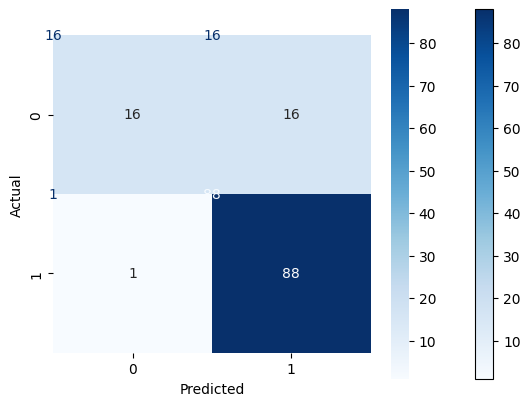

In [179]:
conf_matrix = confusion_matrix(df_y_test, df_y_pred)
ConfusionMatrixDisplay(conf_matrix).plot(cmap='Blues')
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

(0.0, 1.0)

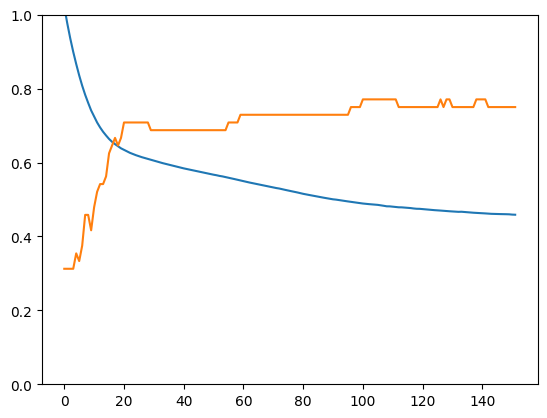

In [180]:
plt.plot(model.loss_curve_)
plt.plot(model.validation_scores_)
plt.ylim(0, 1)

In [181]:
model.coefs_


[array([[-0.01737802,  0.25912619,  0.15273786,  0.03931919, -0.27730572,
         -0.16705527, -0.34233869,  0.2258652 ,  0.03445123,  0.24421553,
         -0.28172294,  0.3640112 ,  0.23556343, -0.10009734, -0.22311153,
         -0.15545472, -0.19294598, -0.01947312,  0.1168501 ,  0.07026034,
          0.10587966, -0.17160248,  0.04496734, -0.14299935,  0.04710199,
          0.16166129, -0.02669315,  0.01541155,  0.05885401, -0.36987664,
         -0.0047526 , -0.1369919 , -0.15240036,  0.25813955,  0.36013782,
          0.22083073, -0.00212356, -0.26574531,  0.07974992, -0.08851246],
        [-0.19504334, -0.04736055, -0.25977006,  0.2643185 , -0.21204846,
          0.1568629 , -0.18023466, -0.00460887,  0.01535547, -0.04317723,
          0.32877294,  0.23220203,  0.30025004,  0.33974224,  0.04461935,
          0.32960139, -0.33030546, -0.07664134, -0.13239767,  0.15467802,
         -0.02248193, -0.08313434,  0.36556054, -0.14039208, -0.06742168,
         -0.01249612,  0.01836687,  0

In [182]:
model.intercepts_

[array([ 0.1151951 , -0.1180084 ,  0.32898049,  0.22696401,  0.17988962,
         0.02326732, -0.10313002, -0.17377454, -0.33913782,  0.37095016,
         0.21259847,  0.37823285,  0.37430393,  0.11443975,  0.16144703,
         0.34279605,  0.1711101 , -0.18985394,  0.09856732, -0.1141611 ,
         0.38431092,  0.12547959, -0.01844144,  0.05438307,  0.14586669,
        -0.12631454, -0.10408522,  0.17039281, -0.01148159,  0.11206534,
        -0.06524053,  0.29903008,  0.14578693, -0.01385282,  0.29665138,
        -0.06806404, -0.0990168 , -0.24042999,  0.13315452,  0.03881027]),
 array([-0.214215])]

In [183]:
sample_rec = df_X_test.sample(3, random_state=42)
sample_rec

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
24,1,1,0,1,1,0.397835,0.000000,0.283931,0.74359,1.0,0.0,1.0,0.0
104,1,1,1,1,0,0.122691,0.114699,0.141966,0.74359,1.0,0.0,0.0,1.0
181,1,1,0,1,0,0.094407,0.238085,0.076443,0.74359,1.0,1.0,0.0,0.0


In [184]:
rst = model.predict(sample_rec)
rst

array([1, 1, 1])

In [185]:
cm = confusion_matrix(df_y_test, df_y_pred)
f1 = f1_score(df_y_test, df_y_pred)
print("Confusion Matrix:\n", cm)
print("F1 Score:", f1)

Confusion Matrix:
 [[16 16]
 [ 1 88]]
F1 Score: 0.9119170984455959


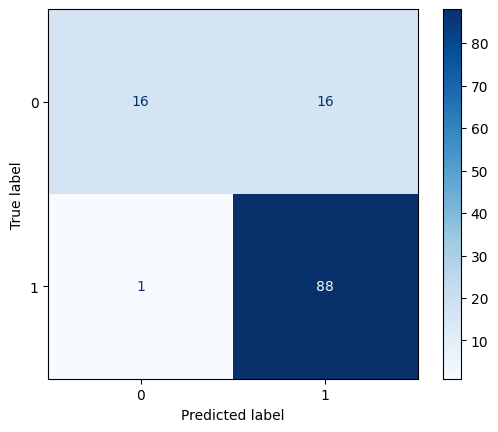

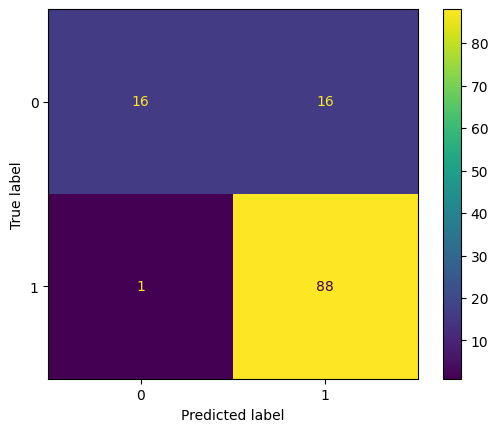

In [187]:
ConfusionMatrixDisplay(cm).plot(cmap='Blues').plot()


In [189]:
print(classification_report(df_y_test, df_y_pred))

              precision    recall  f1-score   support

           0       0.94      0.50      0.65        32
           1       0.85      0.99      0.91        89

    accuracy                           0.86       121
   macro avg       0.89      0.74      0.78       121
weighted avg       0.87      0.86      0.84       121



In [190]:
model.score(df_X_test, df_y_test)

0.859504132231405

In [193]:
pickle.dump(model, open('./data/nn_loan_model.pkl', 'wb'))